# **Project** | Analyzing Website Performance for The Grammys

<div style="text-align: center;">
<img src="https://upload.wikimedia.org/wikipedia/en/thumb/0/01/The_Recording_Academy_logo.svg/2560px-The_Recording_Academy_logo.svg.png" alt="The Recording Academy Logo" width="320"/>
</div>
<br>

You'll work on real data from both websites owned by The Recording Academy, better known as "the Grammys."

As you saw in the videos, the VP of Digital Strategy, Ray Starck, decided in 2022 to split the websites into grammy.comLinks to an external site. and recordingacademy.comLinks to an external site. to better serve the Recording Academy's various audience needs. You're tasked with examining the impact of splitting up the two websites, and analyzing the data for a better understanding of trends and audience behavior.


## Data Dictionary
You'll be working with two files, `grammys_live_web_analytics.csv` and `ra_live_web_analytics.csv`.

These files will contain the following information:

- **date** - The date the data was confirmed. It is in `yyyy-mm-dd` format.
- **visitors** - The number of users who went on the website on that day.
- **pageviews** - The number of pages that all users viewed on the website.
- **sessions** - The total number of sessions on the website. A session is a group of user interactions with your website that take place within a given time frame. For example a single session can contain multiple page views, events, social interactions.
- **bounced_sessions** - The total number of bounced sessions on the website. A bounced session is when a visitor comes to the website and does not interact with any pages / links and leaves.
- **avg_session_duration_secs** - The average length for all session durations for all users that came to the website that day.
- **awards_week** - A binary flag if the dates align with marketing campaigns before and after the Grammys award ceremony was held. This is the big marketing push to get as many eyeballs watching the event.
- **awards_night** - The actual night that Grammy Awards event was held.

# Part 1: Exploring the Data

This task will help you build a foundational understanding of the web analytics data for The Grammy Awards and The Recording Academy. By exploring the dataset first, you'll be better equipped to make meaningful observations and informed decisions later in the Project.


## Task 1

To start, import the both the `pandas` and `plotly.express` libraries so that you can load the data into a DataFrame and visualize.


In [76]:
# Import libraries
import pandas as pd
import plotly.express as px

## Task 2

Load in the first two files for your analysis. They are the `grammy_live_web_analytics.csv` and `ra_live_web_analytics.csv`.


**A.** Read the `grammy_live_web_analytics.csv` file into your notebook. Store the data in a DataFrame named `full_df`.

**B.** Read the `ra_live_web_analytics.csv` file into your notebook. Store that data into a DataFrame called `rec_academy`.

**C.** Preview both DataFrames to familiarize yourself with the data.

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Remeber: </strong>These files can be found in the datasets folder!
</span>
</div>

In [77]:
# Read in dataframes
full_df = pd.read_csv("datasets/grammy_live_web_analytics.csv")
rec_academy = pd.read_csv("datasets/ra_live_web_analytics.csv")

In [78]:
# Preview full_df dataframe
full_df.head()

,date,visitors,pageviews,sessions,bounced_sessions,avg_session_duration_secs,awards_week,awards_night
0,2017-01-01,9611,21407,10196,6490,86,0,0
1,2017-01-02,10752,25658,11350,7055,100,0,0
2,2017-01-03,11425,27062,12215,7569,92,0,0
3,2017-01-04,13098,29189,13852,8929,90,0,0
4,2017-01-05,12234,28288,12990,8105,95,0,0


In [79]:
# Preview rec_academy dataframe
rec_academy.head()

,date,visitors,pageviews,sessions,bounced_sessions,avg_session_duration_secs,awards_week,awards_night
0,2022-02-01,928,2856,1092,591,148,0,0
1,2022-02-02,1329,3233,1490,923,90,0,0
2,2022-02-03,1138,3340,1322,754,127,0,0
3,2022-02-04,811,2552,963,534,142,0,0
4,2022-02-05,541,1530,602,326,111,0,0


## Task 3

The Grammy Awards are among the most prominent events in the global music industry. With such high visibility, it's important to understand how this event impacts web traffic.

**A.** Create a line chart of the number of users on the site for every day in the `full_df`.

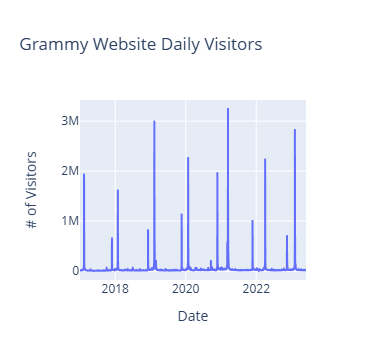

In [80]:
# Plot a line chart of the visitors on the site.
fig = px.line(
    full_df,
    x="date",
    y="visitors",
    title="Grammy Website Daily Visitors",
    labels={"date": "Date", "visitors": "# of Visitors"}
)
fig.show()

**B.** What do you notice about when and why traffic spikes occur? Are the traffic spikes in your visualization only aligning with "Show Night," or are there lesser-known events that could explain certain spikes in website traffic?

<div style="border: 3px solid #30EE99; background-color: #f0fff4; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
    <strong>Try This AI Prompt:</strong> Can you identify any specific lesser-known events (with exact dates) that might have caused significant increases in website traffic on grammys.com? What external data sources could help confirm these trends?
  </span>
</div>

The main spikes occur annually around January-February, with the occasional March an tend to last for a very short time. These spikes line up directly with the "Show Night" for the Grammys. The smaller spikes occur in november or December, and align with the nominations annoucements that occur between mid-November to early December.

## Task 4

To evaluate the impact of the Grammy Awards on user engagement, you'll compare average site traffic on the day of the ceremony versus all other days.

Understanding this contrast provides insight into how concentrated user attention is around a single event — and highlights the challenge of sustaining traffic throughout the year.


**A.** Use the pandas `.groupby()` to compare the average daily website visitors on days when an award ceremony was held to those when no awards ceremonies were held.

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>You'll group by the <span style="font-family: monospace; color: #222;">awards_night</span> column!
</span>
</div>

In [81]:
# Average number of visitors on awards nights versus other nights
avg_visitors = full_df.groupby("awards_night")["visitors"].mean()
avg_visitors

awards_night
0    3.238828e+04
1    1.389590e+06
Name: visitors, dtype: float64

**B.** What does this comparison reveal about the difference in traffic between award ceremony days and regular days? How many more visitors does the Grammy Awards site receive on Show Night?


<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Remark: </strong>This is The Recording Academy's biggest challenge! How do you transform a business that relies on the success of one event per year into one that continues to bring users back on the site year round?
</span>
</div>

This comparison reveals that the actual awards show of the Grammys has an average of nearly 1.4 million visitors a night, while regular days only have an average of about 32 thousand visitors. This constitutes a 42.9x larger visitor count on awards nights compared to regular nights, with an numerical difference of 1,357,202 more visitors a night.

## Task 5

When The Recording Academy split its digital presence across two domains, grammy.com and recordingacademy.com, the data capture for grammy.com was not affected. Meaning, the way visitor data was collected for grammy.com stayed exactly the same before and after the split. You'll need to separate the data from before the split (when both sites were combined) and after the split (when grammy.com data continued independently). The split happened on February 1, 2022 (`2022-02-01`).


Create two new DataFrames:

1. `combined_site` should contain all data with dates before `2022-02-01`.

2. `grammys` should contains all data with dates on or after `2022-02-01`.

In [82]:
# Split the data to separate the full_df into two new dataframes.
# One for before the switch of the websites and one for after

combined_site = full_df[ full_df["date"] < "2022-02-01" ]
grammys = full_df[ full_df["date"] >= "2022-02-01" ]

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Tip: </strong>After creating these DataFrames, best practice is to use the .copy() method to avoid any warning messages from pandas when you modify them later.
</span>
</div>

In [83]:
# Run the following cell - DO NOT MODIFY
# .copy() prevents pandas from printing a warning message
combined_site = combined_site.copy()
grammys = grammys.copy()

In [84]:
# Print the shape of the combined_site dataframe
combined_site.shape

(1857, 8)

<div style="border: 3px solid #f8c43e; background-color: #fff3c1; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
      If done correctly, the <span style="font-family: monospace; color: #222;">combined_site</span> DataFrame should have a total of <strong>1857</strong> rows and <strong>8</strong> columns.
  </span>
</div>



# Part 2: Analyzing Key Metrics

Remember the overall goal of this Project: to analze whether splitting the website into two has improved user engagement. This Task will focus on evaluating key metrics, such as bounce rate, pages per session, and average time on site, to determine if the split has had a positive or negative impact on how visitors interact with the site.

## Task 6

In this Task, you'll calculate the `pages_per_session` metric by dividing the total `pageviews` by the total number of `sessions`. Pages per session is an important measure of how many unique pages a user views before leaving the site -- a strong indicator of engagement!


**A.** Create a new list called `frames` that has each dataframe as an entry. e.g. If there were 3 dataframes, `df1`, `df2`, and `df3`, then the code would look like:

```python
frames = [df1, df2, df3]
```

**B.** `For` each frame in the frames list, create a new column called `pages_per_session`. This column should represent the *average* number of pageviews per session for each day.


<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>Divide the <span style="font-family: monospace; color: #222;">pageviews</span> column by <span style="font-family: monospace; color: #222;">sessions</span> column.
</span>
</div>

This can be achieved by using the following template:

```python
frame['new_col'] = frame['col_A'] / frame['col_B']
```



In [85]:
# Create the `pages_per_session` column for all 3 dataframes.
frames = [combined_site, grammys, rec_academy]
for frame in frames:
    frame['pages_per_session'] = frame['pageviews'] / frame['sessions']

**C.** Visualize this new `pages_per_session` metric using a line chart for each site. You will have 3 separate graphs!

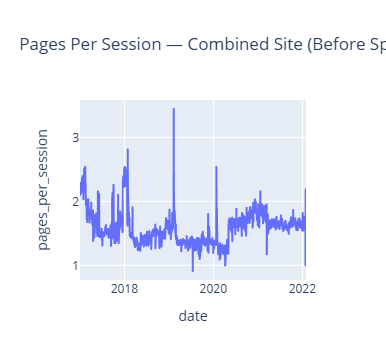

In [86]:
# combined_site graph
fig = px.line(
    combined_site,
    x="date",
    y="pages_per_session",
    title="Pages Per Session — Combined Site (Before Split)"
)
fig.show()

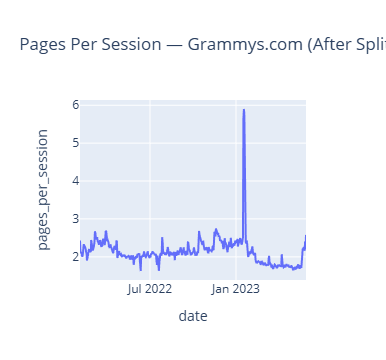

In [87]:
# grammys graph
fig = px.line(
    grammys,
    x="date",
    y="pages_per_session",
    title="Pages Per Session — Grammys.com (After Split)"
)
fig.show()

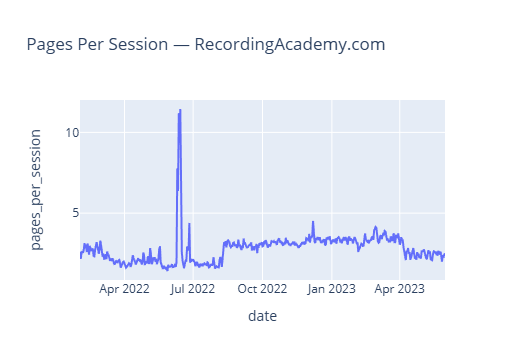

In [88]:
# rec_academy graph
fig = px.line(
    rec_academy,
    x="date",
    y="pages_per_session",
    title="Pages Per Session — RecordingAcademy.com"
)
fig.show()

**D.** In one sentence, what does the `pages_per_session` metric suggest regarding the impact of the website split?

<div style="border: 3px solid #30EE99; background-color: #f0fff4; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
    <strong>Try This AI Prompt:</strong> What does pages per session reveal about user engagement? How should I interpret changes in this metric after the website split?
  </span>
</div>
<br>
<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Note: </strong>Any large spikes in the data that do not correspond with the Grammy Awards Ceremony can be attributed to abnormalities in the data collection process and ignored in your analysis.
</span>
</div>

The pages_per_session metric suggests that the website split had a positive effect on both sites, leaving Grammy.com with a slight boost to interaction but mostly the same as before, but causing people to go through many more pages on average in RecordingAcademy.com, meaning a much deeper interaction with the site.

## Task 7

Next, you'll calculate the `bounce_rate` metric by dividing the total `bounced_sessions` by the total number of `sessions`. Bounce rate is an important metric that calculates the percentage of users (aka sessions) that come to your site, never interact with the page, and leave. They are said to have "bounced" off your home page. It is a measure of how engaging your home page is with users.

**A.** Create a function called `bounce_rate` that:

1. Takes in a `dataframe` as input
2. adds up all of the values in the `bounced_sessions` column and stores in a variable called `sum_bounced`
3. adds up all of the values in the `sessions` column and stores it in a variable called `sum_sessions`
4. returns `100 * sum_bounced / sum_sessions`

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>You will need use the <span style="font-family: monospace; color: #222;">.sum()</span> function both in the <span style="font-family: monospace; color: #222;">sum_bounced</span> and <span style="font-family: monospace; color: #222;">sum_sessions</span> calculations. Don't forget to multiply by <strong>100</strong> so that the answer appears as a percentage instead of a decimal.
</span>
</div>

In [89]:
def bounce_rate(dataframe):
    '''
    Calculates the bounce rate for visitors on the website.
    input: dataframe with bounced_sessions and sessions columns
    output: numeric value from bounce rate
    '''

    # WRITE YOUR CODE HERE
    # Remember, the input for the function is called `dataframe`
    # All calculations must reference that variable.
    sum_bounced = dataframe["bounced_sessions"].sum()
    sum_sessions = dataframe["sessions"].sum()
    return 100 * sum_bounced / sum_sessions

**B.** Use the `frames` variable from Task 6 to loop over each website (represented by a dataframe) to calculate the bounce rate. Print the bounce rate for each site.

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>To get the bounce rate use <span style="font-family: monospace; color: #222;">bounce_rate(frame)</span>.
</span>
</div>

<br>

<div style="border: 3px solid #30EE99; background-color: #f0fff4; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
    <strong>Try This AI Prompt:</strong> How do I show a number with only 2 decimal places in an f-string?
  </span>
</div>

In [90]:
# Calculate the Bounce Rate for each site
for i, frame in enumerate(frames):
    rate = bounce_rate(frame)
    print(f"Site {i+1} Bounce Rate: {rate:.2f}%")

Site 1 Bounce Rate: 41.58%
Site 2 Bounce Rate: 40.16%
Site 3 Bounce Rate: 33.67%


<div style="border: 3px solid #f8c43e; background-color: #fff3c1; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
  If done correctly, the <span style="font-family: monospace; color: #222;">combined_site</span> and <span style="font-family: monospace; color: #222;">grammys</span> site will each have bounce rates in the low 40s. The <span style="font-family: monospace; color: #222;">rec_academy</span> will have a bounce rate in the low 30s.
  </span>
</div>


**C.** Next, you'll calculate the `average_time_on_site metric.`To do this, you only need to calculate the average of the `avg_session_duration_secs` column. Average Time on Site measures how engaging your website experience is for your users. The higher the number, the longer they are staying on your page and engaging with the content.

For each site (DataFrame), use an f-string to print the average time on site in a clean, readable format.

In [91]:
# Calculate the average of the avg_session_duration_secs
for i, frame in enumerate(frames):
    avg_time = frame["avg_session_duration_secs"].mean()
    print(f"Site {i+1} — Average Time on Site: {avg_time:.2f} seconds")

Site 1 — Average Time on Site: 102.85 seconds
Site 2 — Average Time on Site: 82.99 seconds
Site 3 — Average Time on Site: 128.50 seconds


**D.** Which of these three metrics changed the most after the site split? What do these changes suggest about user behavior?

The average time metric changed the most over the site split. The bounce rate stayed mostly the same for Grammy.com and drastically decreased for RecordingAcademy.com suggests that the Grammy portion of the site was making it difficult for people to engage with the academy portion. This is supported by the fact that when average time decreased for the Grammy.com site, while the acadamies increased, meaning that the larger time spent on the academy portion was being tamped down in the total average of the original site by the smaller average time people spent on the grammy portion.

# Part 3: Demographics

Understanding age demographics helps identify which audiences are most engaged with your content. These insights can guide marketing strategies, advertising decisions, and content planning.

You’ll analyze the age demographics for both websites. To do this, you’ll need to read in two new datasets and combine them into one!



## Task 8

The `grammys_age_demographics.csv` and `tra_age_demographics.csv` each contain the following information:

- **age_group** - The age group range. e.g. `18-24` are all visitors between the ages of 18 to 24 who come to the site.
- **pct_visitors** - The percentage of all of the websites visitors that come from that specific age group.

**A.** Read in the `grammys_age_demographics.csv` and `tra_age_demograhics.csv` files and store them into dataframes named `age_grammys` and `age_tra`, respectively.

In [58]:
# Read in the files
age_grammys = pd.read_csv("datasets/grammys_age_demographics.csv")
age_tra = pd.read_csv("datasets/tra_age_demographics.csv")

In [59]:
# Preview the age_grammys file. the age_tra will look very similar.
age_grammys.head()

,age_group,pct_visitors
0,18-24,27.373210
1,25-34,24.129273
2,35-44,18.717867
3,45-54,13.568619
4,55-64,9.817036


**B.** For each dataframe, create a new column called `website` whose value is the name of the website.
e.g. the `age_grammys` values for `website` should all be `Grammys` and for the `age_tra` they should be `Recording Academy`.

In [60]:
# Label rows as 'Recording Academy'
age_grammys["website"] = "Grammys"

# Label rows as 'Grammys'
age_tra["website"] = "Recording Academy"

**C.** use the `pd.concat()` method to join these two datasets together. Store the result into a new variable called `age_df`

<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>Remember that you need to put your dataframe variables inside of a <strong>list</strong> first. Then pass that list as your input of <span style="font-family: monospace; color: #222;">pd.concat()</span>.
</div>

In [92]:
# Concatenate dataframes
age_df = pd.concat([age_grammys, age_tra])

# Preview combined data
age_df

,age_group,pct_visitors,website
0,18-24,27.373210,Grammys
1,25-34,24.129273,Grammys
2,35-44,18.717867,Grammys
3,45-54,13.568619,Grammys
4,55-64,9.817036,Grammys
5,65+,6.393994,Grammys
0,18-24,27.116827,Recording Academy
1,25-34,26.155406,Recording Academy
2,35-44,19.548684,Recording Academy
3,45-54,13.823158,Recording Academy


<div style="border: 3px solid #f8c43e; background-color: #fff3c1; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
  <span style="font-size: 10pt;">
      If done correctly, your new DataFrame will have <strong>12</strong> rows and <strong>3</strong> columns.
  </span>
</div>

**D.** Create a bar chart of the `age_group` and `pct_visitors`. This chart should have, for each age group, one color for the Recording Academy and a different color for the Grammys.


<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>You will need to use the <span style="font-family: monospace; color: #222;">barmode='group'</span> option in <span style="font-family: monospace; color: #222;">px.bar()</span>. See the code snippet below to guide you.
</span>
</div>


```python
# Template for visualization
px.bar(dataframe, x='variable1', y='variable2', color='variable3', barmode='group')
```

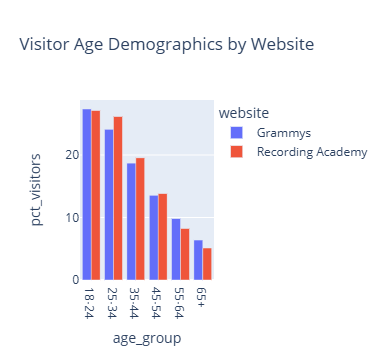

In [93]:
# age_group and pct_visitors bar chart
px.bar(
    age_df,
    x="age_group",
    y="pct_visitors",
    color="website",
    barmode="group",
    title="Visitor Age Demographics by Website"
)

**E.** Looking at the chart above, what can you say about how the age demographics differ between the two websites?

Looking at the chart above, it seems that while there are moderatly more 55-64+ year old users on the Grammys site, and slightly more 25-34 year old on the Recording Academy site, for the most part the age demographics of the sites are similar.

# Part 4: Making a Business Recommendation


## Task 9

Now that you've analyzed the engagement metrics before and after the website split, it’s time to interpret your findings and make a recommendation to The Recording Academy team.


**A.** Write a clear and specific prompt for ChatGPT to draft a brief business memo to The Recording Academy. Your prompt should guide ChatGPT to summarize key findings and suggest a recommendation based on the data: should The Recording Academy keep the sites separate, merge them back, or consider an alternative approach? Paste your prompt below.

Please draft a brief, well written business memo, with minimal errors and grammatical mistakes to The Recording Academy that summarizes these key finsings, and suggests a recommendation based off of the data:

    The Grammys has a massive increase in users over the warards night compared to normal days, constituting a 42.9 times increase with a numerical difference of 1,357,202 more visitors a night.
    
    Before the original combined site split into the Grammys.com and RecordingAcademy.com sites, users would access an average of about 1.7 pages per session. After the split, users average about 2.15 pages per session on the Grammys.com site, and about 2.8 pages per session on the RecordingAcademy.com site.
    
    Combined Site Bounce Rate: 41.58%
    Grammys.com Bounce Rate: 40.16%
    RecordingAcademy.com Bounce Rate: 33.67%
    
    Combined Site — Average Time on Site: 102.85 seconds
    Grammys.com Bounce Rate: — Average Time on Site: 82.99 seconds
    RecordingAcademy.com — Average Time on Site: 128.50 seconds
    
    The age demographics of the split sites remain mostly the same, however, there are moderately more 55-64+ year old users on the Grammys.com site, and slightly more 25-34 year old on the RecordingAcademy.com site.


**B.** What did ChatGPT do well? Did it capture the key trends and insights? What was missing or inaccurate? Were any important details left out or misrepresented?

ChatGPT did suprisinggly well with the prompt. It identified and discussed all of the major trands and insights given to it through the data with no missing information or innacuracies. It did not leavy any details out.

**C.** Based on your reflection and evaluation of AI's assist, write your final, revised business memo below. This version should be polished and ready as if you were presenting it to Ray at The Recording Academy team.

    Hello, I have reviewed the data you requested regarding your Grammys.com and RecordingAcademy.com sites. While looking through the daily user analytics for the Grammys website, I discovered a trend of usage rapidly spiking on an annual basis during the nominations announcements and the awards night, before settling back to a far lower stable level. Based on these spikes, during the awards show, the Grammys site has an average of nearly 1.4 million visitors a night, while regular days only have an average of about 32 thousand visitors. This is a massive difference from the typical site traffic.

    In regards to site split a few years ago, I noticed that the average number of pages users opened per session had a large increase after the site split, with a particularly large increase being observed for the RecordingAcademy.com site. I can tell from this data that the split has had a positive effect on user engagement of both sites. As well, while the bounce rate of the Grammys.com site stayed nearly identical to that of the original site (both low 40%), the bounce rate of the RecordingAcademy.com site decreased drastically to 33.67%. This means that users have been better able to engage with the RecordingAcademy.com site due to the newer, more streamlined features stemming from the split.
    
    When comparing the average time spent on each site by users, I noticed a major change between the pre and post split values. Before splitting, the combined site showed an average time of around 103 seconds, but after the split, Grammys.com showed an average of around 83 seconds, and RecordingAcademy.com displayed an average of nearly 129 seconds. From this discrepancy, I can infer that the initial average, which took into account users from both portions of the site, was being skewed by the differences between its divided user base. Those who made use of the Recording Academy portion spent more time interacting with the site in total, while those interested in the Grammy portion spent less time interacting with the site, resulting in the average of the combined site being remarkably close to the average of the average times users spent on both sub-sites.
    
    Finally, I noticed that though the demographics remained mostly identical between the two sites, there were two differences. Firstly, the Grammys.com site tended to attract moderately more users in the 55-64+ age brackets. Secondly, the RecordingAcademy.com site tended to attract slightly more users in the 25-34 age brackets.
    
    Based on these findings I recommend the following: From clear improvements displayed in both sites when compared to the original shared site, I can advise that you should continue to invest in separate, audience specific site experiences for each site. With the slight differences in demographics, I believe that you should focus the Grammys site to cater more towards those of older age, while pivoting the RecordingAcademy.com site towards a slightly younger audience. I also recommend that the Grammys site should work to construct a framework that tailors itself more to the awards night visitors, with enhanced coverage and easier navigation for event specific content, as that makes up the major bulk of total use on that site.


# LevelUp

Ray and Harvey are both interested to see how the Grammys.com website compares to that of their main music award competitor, The American Music Awards (AMA). The dashboard below is aggregated information about the performace of The AMA website for the months of April, May, and June of 2023.

Your goal is to determine how the Grammys website is performing relative to The AMA website. In particular, you will be looking at the device distribution and total visits over the same time span and leveraging information about Visit Duration, Bounce Rate, and Pages / Visit from your work in the core of this project.


![](figs/TheAMAs.png)



The **Total Visits** column is the total number of visitors on the website during the timespan given.
The **Device Distribution** is the percentage share of visitors coming from Desktop users (PCs, Macs, etc.) and Mobile Users (iPhone, Android, etc.).

Visitors on the AMA website are spending on average, 5 mins and 53 seconds on the site and viewing 2.74 pages per visit (aka session). They have a bounce rate of 54.31%

**A.** Load in the two files. The `desktop_users.csv` and `mobile_users.csv` files contain the users coming from desktop users and mobile users respectively.

Store them in variables named `desktop_users` and `mobile_users`

In [66]:
# Load in the data
desktop_users = pd.read_csv("datasets/desktop_users.csv")
mobile_users = pd.read_csv("datasets/mobile_users.csv")

In [67]:
# Preview the desktop_users file
desktop_users.head()

,date,segment,visitors
0,2022-02-01,Desktop Traffic,10195
1,2022-02-02,Desktop Traffic,10560
2,2022-02-03,Desktop Traffic,9935
3,2022-02-04,Desktop Traffic,8501
4,2022-02-05,Desktop Traffic,5424


In [68]:
# Preview mobile_users file
mobile_users.head()

,date,segment,visitors
0,2022-02-01,Mobile Traffic,23494
1,2022-02-02,Mobile Traffic,20234
2,2022-02-03,Mobile Traffic,22816
3,2022-02-04,Mobile Traffic,18592
4,2022-02-05,Mobile Traffic,13298


As you can imagine, you will be joining the two datasets together! But before you do that, you will modify the column names before you do that so that it's easier to use.

**B.** For each dataframe, change the name of the `visitors` column so that it says which category they come from. For example, the `desktop_users` dataframe should have a column named `desktop_visitors` instead of `visitors`.

Additionally, drop the `segment` column since it is no longer needed.

In [69]:
# Change name of the visitors column to indicate which category it comes from
desktop_users = desktop_users.rename(columns={"visitors": "desktop_visitors"})
mobile_users = mobile_users.rename(columns={"visitors": "mobile_visitors"})

In [70]:
# Drop the segment column from each dataframe
desktop_users = desktop_users.drop(columns=["segment"])
mobile_users = mobile_users.drop(columns=["segment"])

**C.** Join the two dataframes together in a new variable called `segment_df`.

In [71]:
# Join the two dataframes and preview the dataframe
segment_df = pd.merge(desktop_users, mobile_users, on="date")

**D.** In the next few steps, you will calculate the percentage share of users coming from desktop and mobile on the Grammys website.

Calculate a new column, `total_visitors` that is the addition of `desktop_visitors` and `mobile_visitors`.

In [72]:
# Create total_visitors column
segment_df

,date,desktop_visitors,mobile_visitors
0,2022-02-01,10195,23494
1,2022-02-02,10560,20234
2,2022-02-03,9935,22816
3,2022-02-04,8501,18592
4,2022-02-05,5424,13298
...,...,...,...
510,2023-06-26,4302,7327
511,2023-06-27,5528,9491
512,2023-06-28,4928,9856
513,2023-06-29,5554,12881


<div style="border: 3px solid #b67ae5; background-color: #f9f1ff; padding: 15px; border-radius: 8px; color: #222; display: flex; align-items: center;">
<span style="font-size: 10pt;">
<strong>Hint: </strong>To calculate the percentage share you will first need to filter the data to dates after (and including) `2023-04-01`. Then calculate the `sum` of desktop visitors and total visitors and divide those values. The percentage share of mobile visitors will be the value needed to get to 100%.
</span>
</div>



In [75]:
# Filter and calculate the percentage share
# Use an f string to print each percentage to the screen
segment_df["total_visitors"] = (
    segment_df["desktop_visitors"] + segment_df["mobile_visitors"]
)
filtered = segment_df[segment_df["date"] >= "2023-04-01"]
sum_desktop = filtered["desktop_visitors"].sum()
sum_mobile = filtered["mobile_visitors"].sum()
sum_total  = filtered["total_visitors"].sum()
pct_desktop = 100 * sum_desktop / sum_total
pct_mobile  = 100 * sum_mobile / sum_total

print(f"Desktop visitors make up a {pct_desktop:.2f}% share of the total users.")
print(f"Mobile visitor make up a {pct_mobile:.2f}% share of the total users")

Desktop visitors make up a 31.84% share of the total users.
Mobile visitor make up a 68.16% share of the total users


**E.** How is the Grammys website performing relative to its competitor? What is the Grammys doing well and what KPIs does it need to improve?

    Relative to the AMA, the Grammys website has a much lower bounce rate (~40% compare to the ~54% of the AMA). However, the Grammys falls short when it comes to and average time statistics, with the AMA's 5min 53sec average blowing the 1min 23sec average of the Grammys out of the water. As well 2.74 pages per session of the AMA is much greater than the ~2.15 average of the Grammys site. Finally, while the AMA gets the vast majority of its users from mobile devices, the Grammys has a much more balanced 1:2 split between desktop and mobile users.